# Esercizio

### 1. Dataset sintetico
Si generi un dataset bidimensionale sintetico `X, y` composto da due classi.

Visualizzare il dataset in uno scatter plot, utilizzando colori diversi per ciascuna classe.


### 2. Riduzione dimensionale (PCA)
Proiettare il dataset `X` in uno spazio ridotto a 1 dimensione utilizzando PCA.

Visualizzare i dati proiettati su un singolo asse, mostrando la separazione tra le classi.


### 3. Classificazione
Addestrare un modello di **Logistic Regression** sui dati proiettati (1D).

Visualizzare:
- la distribuzione delle due classi nello spazio ridotto
- la **frontiera decisionale** del modello


### 4. Ricostruzione nello spazio originale
Riportare la frontiera decisionale nel piano originale 2D.

Visualizzare:
- i dati originali
- la frontiera decisionale nel piano 2D

### Obiettivo
Comprendere come una classificazione effettuata in uno spazio ridotto tramite PCA possa essere reinterpretata nello spazio originale, mantenendo la coerenza geometrica della frontiera decisionale.


### 5. Estensione a 3 dimensioni

Ripetere l'intera procedura dei punti 1–4 utilizzando un dataset sintetico a **3 features**.

In particolare:
- generare un dataset tridimensionale con due classi;
- applicare PCA per ridurre la dimensionalità da 3D a 2D;
- addestrare un modello di Logistic Regression sullo spazio ridotto a 2 dimensioni;
- visualizzare la distribuzione delle classi e la frontiera decisionale nello spazio 2D;
- riportare (tramite trasformazione inversa della PCA) la frontiera decisionale nello spazio originale 3D;
- visualizzare i dati originali e la frontiera decisionale nel sistema tridimensionale.

## 1. Creazione dataset

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression

X, y = make_classification(
    n_samples=50,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=.8,
    random_state=100
)

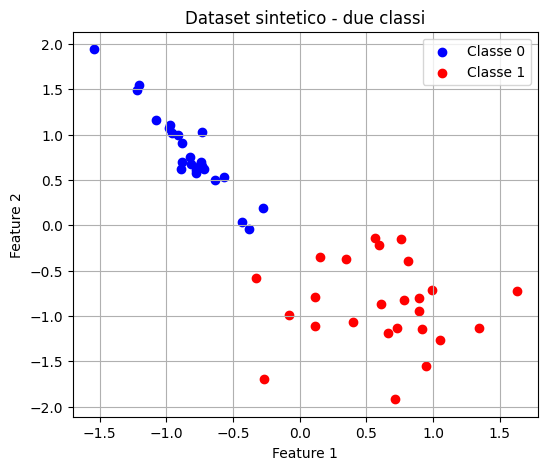

In [36]:
plt.figure(figsize=(6, 5))

plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], 
            color='blue', label='Classe 0')

plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], 
            color='red', label='Classe 1')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Dataset sintetico - due classi")
plt.legend()
plt.grid(True)

plt.show()

## 2. PCA

In [37]:
# matrice di covarianza
n = X.shape[0]
X_c = X - X.mean(axis=0) # centratura

C = (X_c.T @ X_c) / (n - 1)

In [38]:
eigenvalues , eigenvectors = np.linalg.eigh(C)   # autovettori sulle colonnne

In [14]:
print(eigenvectors)

[[-0.76211931 -0.64743661]
 [-0.64743661  0.76211931]]


In [39]:
ei_max = np.argmax(eigenvalues)
print(ei_max)
print("Varianza catturata:", eigenvalues[ei_max]/eigenvalues.sum())

1
Varianza catturata: 0.9310498404362066


In [40]:
W = eigenvectors[:, ei_max]  # un array, non una matrice!
print(W)

[-0.63904229  0.7691716 ]


In [27]:
X_pca = X_c @ W  # un array

print(X_pca)

[ 0.87625836  1.14302692  1.14913861 -1.30882411 -1.09904426  1.20586744
 -0.65321876  0.31618482  1.68521045  1.0938041   2.06143197 -1.78313616
 -1.64687616  2.58003299 -1.25170995  2.02461114 -1.9147306   1.04073389
 -1.37285762  1.50020885  1.07602313 -1.23541737 -1.97138002 -1.51215691
  1.5594245  -1.48517985 -0.78436999 -1.51543965  1.35897307  1.45538104
 -1.00513558 -0.54451681  0.4045871  -2.10369503  0.4301243  -0.731695
 -0.40875344  1.20653384  1.57270144 -0.69190175 -0.87890132 -1.29521971
 -1.81981171 -1.36379334  1.36492954  1.04505659  0.89295264  1.1157303
 -0.85218649  1.07102458]


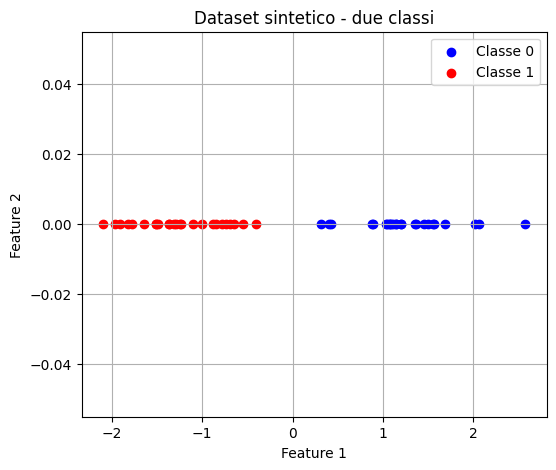

In [41]:
plt.figure(figsize=(6, 5))

plt.scatter(X_pca[y == 0], [0]*np.sum(y == 0), 
            color='blue', label='Classe 0')

plt.scatter(X_pca[y == 1], [0]*np.sum(y == 1), 
            color='red', label='Classe 1')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Dataset sintetico - due classi")
plt.legend()
plt.grid(True)

plt.show()

## 3. Classificazione

In [29]:
X_pca.reshape(-1, 1)

array([[ 0.87625836],
       [ 1.14302692],
       [ 1.14913861],
       [-1.30882411],
       [-1.09904426],
       [ 1.20586744],
       [-0.65321876],
       [ 0.31618482],
       [ 1.68521045],
       [ 1.0938041 ],
       [ 2.06143197],
       [-1.78313616],
       [-1.64687616],
       [ 2.58003299],
       [-1.25170995],
       [ 2.02461114],
       [-1.9147306 ],
       [ 1.04073389],
       [-1.37285762],
       [ 1.50020885],
       [ 1.07602313],
       [-1.23541737],
       [-1.97138002],
       [-1.51215691],
       [ 1.5594245 ],
       [-1.48517985],
       [-0.78436999],
       [-1.51543965],
       [ 1.35897307],
       [ 1.45538104],
       [-1.00513558],
       [-0.54451681],
       [ 0.4045871 ],
       [-2.10369503],
       [ 0.4301243 ],
       [-0.731695  ],
       [-0.40875344],
       [ 1.20653384],
       [ 1.57270144],
       [-0.69190175],
       [-0.87890132],
       [-1.29521971],
       [-1.81981171],
       [-1.36379334],
       [ 1.36492954],
       [ 1

In [42]:
model = LogisticRegression(max_iter=10000)
model.fit(X_pca.reshape(-1, 1), y)

w_log = model.coef_[0]
b = model.intercept_[0]

print(w_log, b)

[-2.60324118] -0.02268614042814291


In 1D il piano è: `z*w_log[0] + b = 0` dove `z` è la variabile nel piano 1D. Ovvero `z = -b/w_log[0]`

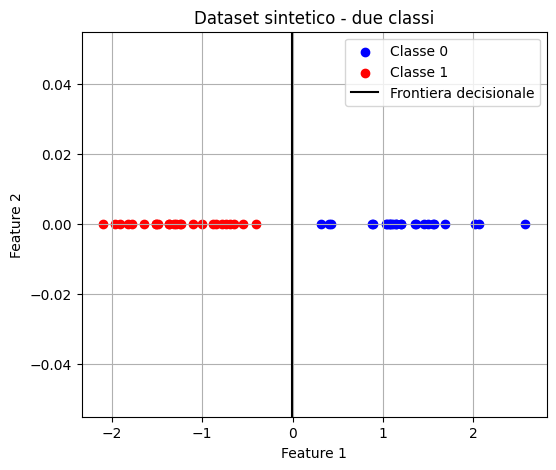

In [43]:
plt.figure(figsize=(6, 5))

plt.scatter(X_pca[y == 0], [0]*np.sum(y == 0), 
            color='blue', label='Classe 0')

plt.scatter(X_pca[y == 1], [0]*np.sum(y == 1), 
            color='red', label='Classe 1')


# Disegno retta
z = -b / w_log[0]
plt.axvline(z, color='black', label='Frontiera decisionale')

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Logistic Regression")
plt.legend()
plt.grid(True)


plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Dataset sintetico - due classi")
plt.legend()
plt.grid(True)

plt.show()

## 4. Ricostruzione

- La frontiera decisionale in 1D è  `w_log*z +b = 0` dove `z = x_vect @ v` e `v` l'autovettore che cattura la massima varianza.
- Se  `mu` è il vettore delle medie delle features allora `z = (x-mu[0])*v[0] + (y-mu[1])*v[i] ` dove `(x, y) = x_vect`.
- Sostituiamo `z` nella frontiera decisionale
  
  `w_log*( (x-mu[0])*v[0] + (y-mu[1])*v[i] ) + b = 0`

  ovvero

  `w_log*(x-mu[0])*v[0] + w_log*(y-mu[1])*v[i] + b = 0`

  Sia `a0 = w_log*v[0]` e `a1 = w_log*v[1]`

  `a0*(x-mu[0]) + a1*(y-mu[1]) + b = 0`

  Quindi

  `y = mu[1] - (b+a0*(x-mu[0]))/a1` 

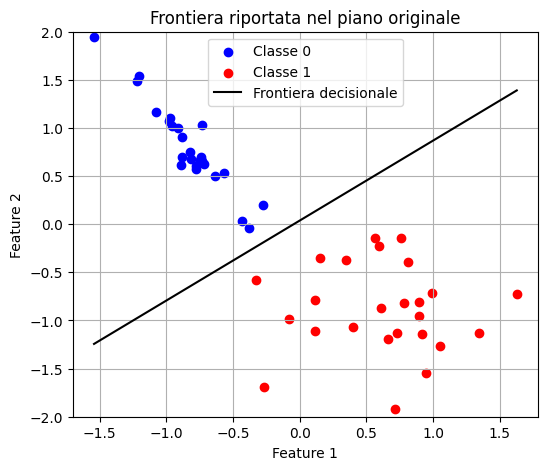

In [44]:
# vettore principale PCA
v = W

# media originale
mu = X.mean(axis=0)

# coefficienti retta nel piano originale
a0 = w_log[0] * v[0]
a1 = w_log[0] * v[1]


# plot dati originali
plt.figure(figsize=(6,5))

plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1],
            color='blue', label='Classe 0')

plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1],
            color='red', label='Classe 1')

# retta decisionale
x_vals = np.linspace(X[:,0].min(), X[:,0].max(), 200)

y_vals = mu[1] - (b+a0*(x_vals-mu[0]))/a1

plt.plot(x_vals, y_vals,
         color='black',
         label='Frontiera decisionale')

plt.ylim(-2, 2)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Frontiera riportata nel piano originale")

plt.legend()
plt.grid(True)
plt.show()

## 5. Estensione 3D

### 5.1. Dataset 3d

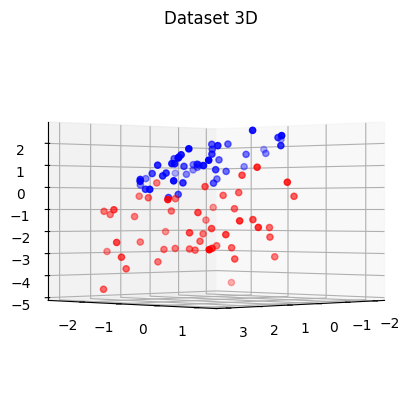

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression

# =========================================================
# 1. DATASET 3D
# =========================================================
X, y = make_classification(
    n_samples=100,
    n_features=3,
    n_informative=3,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=1,
    random_state=0
)

# scatter 3D (proiezione semplice su 2 dimensioni per visualizzare)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X[y==0][:,0], X[y==0][:,1], X[y==0][:,2], color='blue')
ax.scatter(X[y==1][:,0], X[y==1][:,1], X[y==1][:,2], color='red')

ax.view_init(elev=0, azim=45)

plt.title("Dataset 3D")
plt.show()


### 5.2. PCA

In [48]:
# =========================================================
# 2. PCA (3D → 2D)
# =========================================================
mu = X.mean(axis=0)
X_c = X - mu

C = (X_c.T @ X_c) / (X.shape[0] - 1)

eigenvalues, eigenvectors = np.linalg.eigh(C)

# prendo le 2 componenti principali
idx = np.argsort(eigenvalues)[::-1]
W = eigenvectors[:, idx[:2]]

# proiezione in 2D
X_pca = X_c @ W

### 5.3. Classificazione

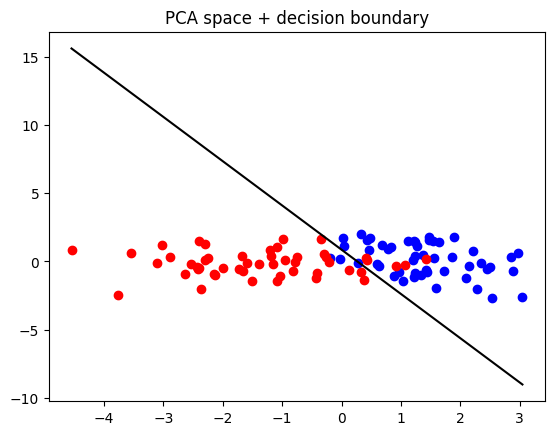

In [49]:
# =========================================================
# 3. LOGISTIC REGRESSION IN 2D PCA
# =========================================================
model = LogisticRegression()
model.fit(X_pca, y)

w_log = model.coef_[0]
b = model.intercept_[0]

# =========================================================
# 4. FRONTIERA DECISIONALE NELLO SPAZIO PCA
# =========================================================
plt.figure()

plt.scatter(X_pca[y==0][:,0], X_pca[y==0][:,1], color='blue')
plt.scatter(X_pca[y==1][:,0], X_pca[y==1][:,1], color='red')

# retta: w0 x + w1 y + b = 0
x_vals = np.linspace(X_pca[:,0].min(), X_pca[:,0].max(), 200)
y_vals = -(w_log[0]*x_vals + b) / w_log[1]

plt.plot(x_vals, y_vals, color='black')

plt.title("PCA space + decision boundary")
plt.show()

### 5.4 Inversione

`x` in D3 viene proiettato in `z = (x-mu) @ W` in D2 (la matrice W 3x2).

La retta di separazione ottenuta dalla regressione logistica è `z w_log + b = 0` (prodotto scalare).

Sostituiamo il valore del punto `z` proiezione di `x` nell'equazione della retta

`( (x-mu)@W) w_log) + b = 0`

oppure

`(x-mu) (W @ w_log) + b = 0`

Sia

`A = W @ w_log` (in $R^3$)

l'equazione del piano diventa

`x A - mu A + b = 0`

e se `C = b-mu A` allora

`x A + C = 0`

Sia `x = (xx, yy, zz)`, la precedente diventa

`xx*A[0] + yy*A[1] + zz*A[2] + C = 0`

Risolvendo rispetto a `zz`

`zz = -(A[0]*xx + A[1]*yy + C) / A[2]`


In [51]:
A =  W @ w_log   # vettore 3D
C = b - A @ mu

# griglia 2D dominio del piano 
xx, yy = np.meshgrid(
    np.linspace(X[:,0].min(), X[:,0].max(), 10),
    np.linspace(X[:,1].min(), X[:,1].max(), 10)
)

# calcolo della terza coordinata per ogni punto della griglia
zz = -(A[0]*xx + A[1]*yy + C) / A[2]

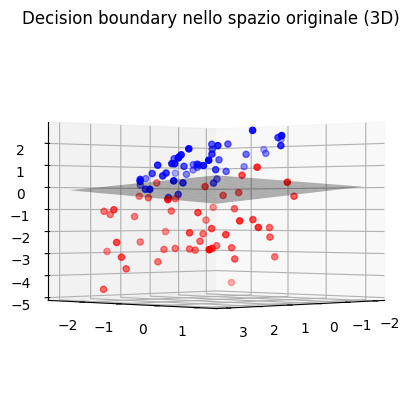

In [53]:
# =========================================================
# 6. PLOT 3D CON PIANO DECISIONALE
# =========================================================
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X[y==0][:,0], X[y==0][:,1], X[y==0][:,2], color='blue')
ax.scatter(X[y==1][:,0], X[y==1][:,1], X[y==1][:,2], color='red')

ax.plot_surface(xx, yy, zz, alpha=0.3, color='black')

ax.view_init(elev=0, azim=45)

plt.title("Decision boundary nello spazio originale (3D)")
plt.show()